## Sri Lanka Economic Sentiment Index (SL-ESI) - Complete EDA & Analysis

This notebook provides a comprehensive exploratory data analysis of the 
Sri Lanka Economic Sentiment Index project, covering:
- News data collection and preprocessing
- Sentiment analysis using FinBERT
- Economic indicators integration
- Correlation analysis
- Key events impact
- Forecasting results
- Key insights and conclusions


### Project Overview
This project analyzes the relationship between news media sentiment and Sri Lanka's economic indicators from 2020-2026, covering:
- **Pre-crisis period** (2020-2021)
- **Economic crisis** (2022)
- **Recovery phase** (2023-2026)

### Key Objectives
1. Quantify economic sentiment from news articles using NLP
2. Correlate sentiment with macroeconomic indicators
3. Identify leading/lagging relationships
4. Forecast future sentiment trends

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

1. Data Loading & Overview

In [6]:
# Processed data
merged_df = pd.read_csv('src/data/processed/sl_esi_merged_economic.csv', parse_dates=['year_month'])
monthly_index = pd.read_csv('src/data/processed/sl_esi_monthly_index.csv')
tourism_df = pd.read_csv('src/data/processed/sl_tourism_monthly.csv')
inflation_df = pd.read_csv('src/data/processed/sl_inflation_rate.csv')
exchange_df = pd.read_csv('src/data/processed/sl_usd_lkr_exchange.csv')
correlation_df = pd.read_csv('src/data/processed/correlation_summary.csv')
forecast_df = pd.read_csv('src/data/processed/sl_esi_forecast_results.csv')

# Raw data
news_raw = pd.read_csv('src/data/raw/news_headlines_raw.csv',parse_dates=['date'])
news_clean = pd.read_csv('src/data/processed/news_headlines_clean.csv',parse_dates=['date'])

# Reference data
key_events = pd.read_csv('src/data/reference/key_events.csv',parse_dates=['date'])

print(f"\nDataset Summary:")
print(f"  - Merged Economic Data: {len(merged_df)} rows")
print(f"  - Monthly Index: {len(monthly_index)} rows")
print(f"  - News Articles (Raw): {len(news_raw)} rows")
print(f"  - News Articles (Clean): {len(news_clean)} rows")
print(f"  - Key Events: {len(key_events)} events")
print(f"  - Forecast Results: {len(forecast_df)} rows")


Dataset Summary:
  - Merged Economic Data: 79 rows
  - Monthly Index: 79 rows
  - News Articles (Raw): 5877 rows
  - News Articles (Clean): 5877 rows
  - Key Events: 12 events
  - Forecast Results: 12 rows


2. News Data Collection & Preprocessing

2.1 Data Collection Statistics

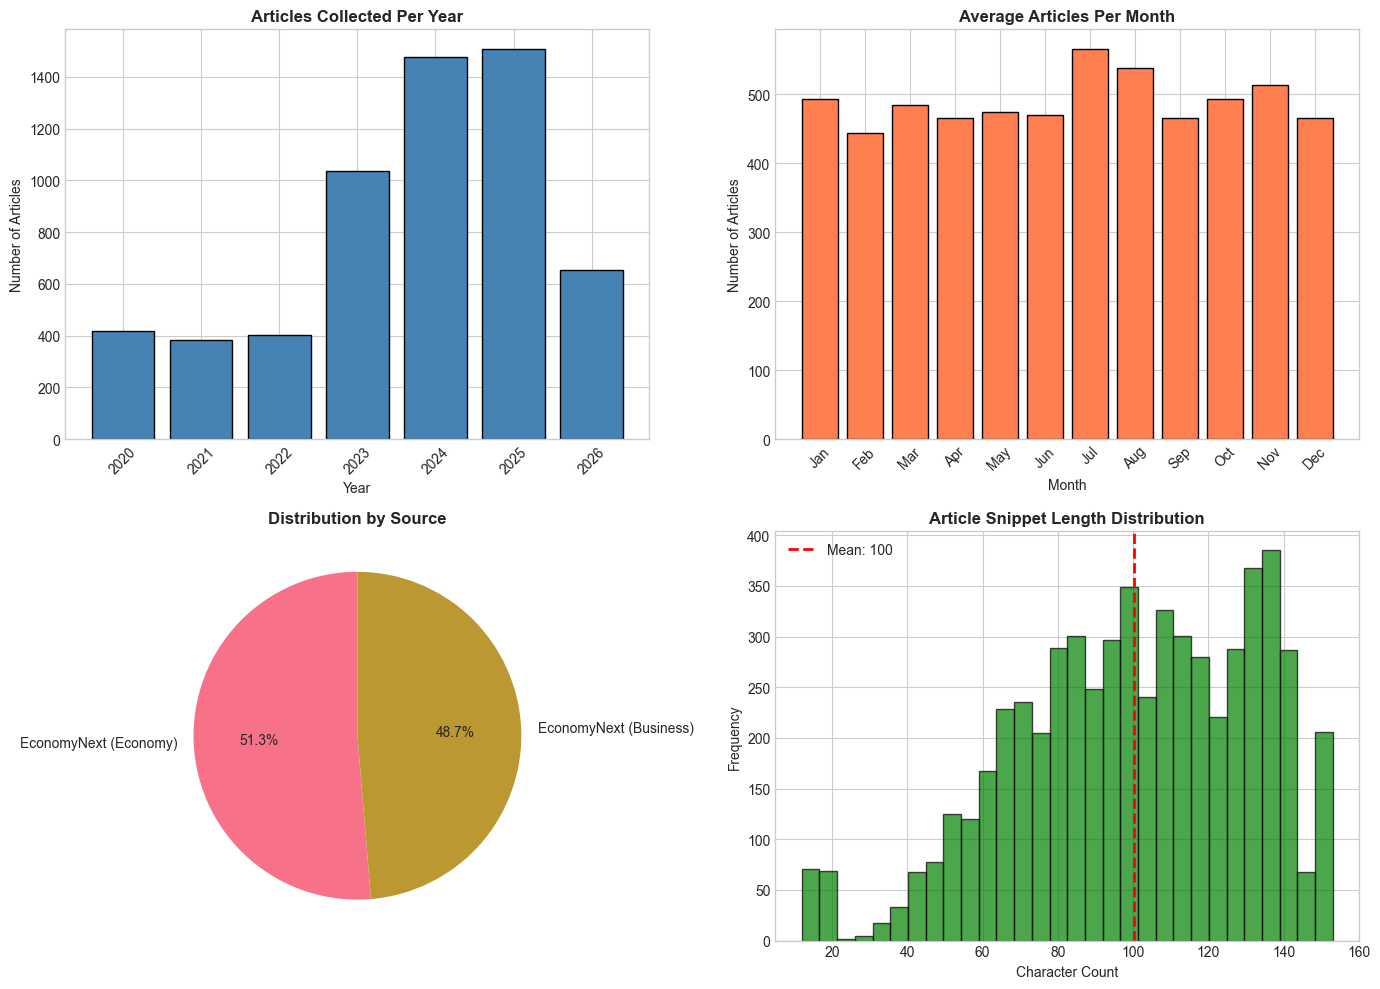

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Articles per year
news_clean['year'] = news_clean['date'].dt.year
yearly_counts = news_clean['year'].value_counts().sort_index()

axes[0, 0].bar(yearly_counts.index, yearly_counts.values, 
                color='steelblue', edgecolor='black')
axes[0, 0].set_title('Articles Collected Per Year', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Articles')
axes[0, 0].tick_params(axis='x', rotation=45)

# Articles per month (average)
news_clean['month'] = news_clean['date'].dt.month
monthly_avg = news_clean.groupby('month').size()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].bar(months, monthly_avg.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Average Articles Per Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Articles')
axes[0, 1].tick_params(axis='x', rotation=45)

# Data sources
if 'source' in news_clean.columns:
    source_counts = news_clean['source'].value_counts()
    axes[1, 0].pie(source_counts.values, labels=source_counts.index, 
                   autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Distribution by Source', fontweight='bold')

# Article length distribution (if snippet available)
if 'snippet' in news_clean.columns:
    news_clean['snippet_length'] = news_clean['snippet'].fillna('').str.len()
    axes[1, 1].hist(news_clean['snippet_length'], bins=30, 
                    color='green', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(news_clean['snippet_length'].mean(), 
                       color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {news_clean["snippet_length"].mean():.0f}')
    axes[1, 1].set_title('Article Snippet Length Distribution', fontweight='bold')
    axes[1, 1].set_xlabel('Character Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

2.2 Sample Articles


In [9]:
# Crisis period (2022)
crisis_articles = news_clean[news_clean['date'].dt.year == 2022].sample(3)
print("\n📰 CRISIS PERIOD (2022):")
for idx, row in crisis_articles.iterrows():
    print(f"\nDate: {row['date'].strftime('%Y-%m-%d')}")
    print(f"Title: {row['title'][:100]}...")
    if 'snippet' in row:
        print(f"Snippet: {str(row['snippet'])[:150]}...")

# Recovery period (2024-2025)
recovery_articles = news_clean[
    (news_clean['date'].dt.year >= 2024) & 
    (news_clean['date'].dt.year <= 2025)
].sample(3)

print("\n\n📈 RECOVERY PERIOD (2024-2025):")
for idx, row in recovery_articles.iterrows():
    print(f"\nDate: {row['date'].strftime('%Y-%m-%d')}")
    print(f"Title: {row['title'][:100]}...")
    if 'snippet' in row:
        print(f"Snippet: {str(row['snippet'])[:150]}...")


📰 CRISIS PERIOD (2022):

Date: 2022-08-02
Title: Sri Lanka state sector workers called back to work on Fridays...
Snippet: The decision that was valid for three months has been cancelled with immediate effect. By By Neshella Perera August 2, 2022...

Date: 2022-06-07
Title: Sri Lanka to write off small-time farmers' debt 100 percent...
Snippet: “We know that farming families who cultivate paddy on small lands are in a very precarious position." June 7, 2022...

Date: 2022-10-30
Title: Sri Lanka's Ceylon Tea prices fall for the third week...
Snippet: Rupee average rose to as much as 1676.93 rupees a kilo in the first week of October. October 30, 2022...


📈 RECOVERY PERIOD (2024-2025):

Date: 2025-01-13
Title: Sri Lanka central bank revalues restructured bonds booking profit...
Snippet: The central bank's net assets, were barely in the positive since the domestic debt re-structure January 13, 2025...

Date: 2024-10-25
Title: Sri Lanka in talks to end Israel linked travel advisories, fu

3. Sentiment Analysis Results

3.1 Sentiment Distribution Over Time

In [11]:
# Create visualization
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Monthly Article Count', 'Sentiment Intensity Over Time'),
                    vertical_spacing=0.12)

# Article count
fig.add_trace(
    go.Bar(x=monthly_index['year_month'], y=monthly_index['article_count'],
           name='Article Count', marker_color='steelblue'),
    row=1, col=1
)

# Sentiment intensity
fig.add_trace(
    go.Scatter(x=monthly_index['year_month'], y=monthly_index['sentiment_intensity'],
               name='Sentiment Intensity', mode='lines+markers',
               line=dict(color='coral', width=3),
               marker=dict(size=6)),
    row=2, col=1
)

# Add crisis period highlight
fig.add_vrect(x0="2022-01", x1="2022-12", 
              annotation_text="Economic Crisis", 
              annotation_position="top left",
              fillcolor="red", opacity=0.1, line_width=0,
              row=1, col=1)
fig.add_vrect(x0="2022-01", x1="2022-12",
              fillcolor="red", opacity=0.1, line_width=0,
              row=2, col=1)

fig.update_layout(
    height=700,
    showlegend=True,
    template='plotly_white',
    title_text="SL-ESI: News Volume & Sentiment Trends (2020-2026)",
    title_font_size=16
)

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Number of Articles", row=1, col=1)
fig.update_yaxes(title_text="Sentiment Intensity", row=2, col=1)

fig.show()

3.2 Sentiment Statistics

In [12]:
print(f"\n Overall Statistics (2020-2026):")
print(f"  Total Articles Analyzed: {monthly_index['article_count'].sum():,}")
print(f"  Time Period: {monthly_index['year_month'].min()} to {monthly_index['year_month'].max()}")
print(f"  Average Articles/Month: {monthly_index['article_count'].mean():.1f}")

print(f"\n Sentiment Metrics:")
print(f"  Mean Sentiment: {monthly_index['mean_sentiment'].mean():.4f}")
print(f"  Std Sentiment: {monthly_index['mean_sentiment'].std():.4f}")
print(f"  Min Sentiment: {monthly_index['mean_sentiment'].min():.4f}")
print(f"  Max Sentiment: {monthly_index['mean_sentiment'].max():.4f}")

print(f"\n Sentiment Intensity:")
print(f"  Mean Intensity: {monthly_index['sentiment_intensity'].mean():.4f}")
print(f"  Std Intensity: {monthly_index['sentiment_intensity'].std():.4f}")
print(f"  Min Intensity: {monthly_index['sentiment_intensity'].min():.4f}")
print(f"  Max Intensity: {monthly_index['sentiment_intensity'].max():.4f}")

# By year
print(f"\n Year-wise Breakdown:")
monthly_index['year'] = pd.to_datetime(monthly_index['year_month']).dt.year
yearly_stats = monthly_index.groupby('year').agg({
    'article_count': 'sum',
    'mean_sentiment': 'mean',
    'sentiment_intensity': 'mean'
}).round(4)

print(yearly_stats.to_string())


 Overall Statistics (2020-2026):
  Total Articles Analyzed: 5,877
  Time Period: 2020-02 to 2026-08
  Average Articles/Month: 74.4

 Sentiment Metrics:
  Mean Sentiment: 0.0326
  Std Sentiment: 0.1464
  Min Sentiment: -0.4516
  Max Sentiment: 0.3559

 Sentiment Intensity:
  Mean Intensity: 0.1687
  Std Intensity: 0.5612
  Min Intensity: -1.3053
  Max Intensity: 1.3915

 Year-wise Breakdown:
      article_count  mean_sentiment  sentiment_intensity
year                                                    
2020            417         -0.0027              -0.0611
2021            383          0.0208               0.0706
2022            403         -0.1078              -0.3437
2023           1036          0.0027               0.0325
2024           1477          0.0895               0.4288
2025           1508          0.1041               0.5012
2026            653          0.1621               0.7158


3.3 Most Positive & Negative Months

In [14]:
# Top 5 positive months
top_positive = monthly_index.nlargest(5, 'sentiment_intensity')
print("TOP 5 MOST POSITIVE MONTHS")
for idx, row in top_positive.iterrows():
    print(f"\n{row['year_month']}")
    print(f"  Articles: {row['article_count']}")
    print(f"  Mean Sentiment: {row['mean_sentiment']:.4f}")
    print(f"  Sentiment Intensity: {row['sentiment_intensity']:.4f}")

print("\n" + "="*80)

# Top 5 negative months
top_negative = monthly_index.nsmallest(5, 'sentiment_intensity')
print("TOP 5 MOST NEGATIVE MONTHS")
for idx, row in top_negative.iterrows():
    print(f"\n{row['year_month']}")
    print(f"  Articles: {row['article_count']}")
    print(f"  Mean Sentiment: {row['mean_sentiment']:.4f}")
    print(f"  Sentiment Intensity: {row['sentiment_intensity']:.4f}")

TOP 5 MOST POSITIVE MONTHS

2026-07
  Articles: 82
  Mean Sentiment: 0.3149
  Sentiment Intensity: 1.3915

2020-08
  Articles: 40
  Mean Sentiment: 0.3559
  Sentiment Intensity: 1.3215

2026-08
  Articles: 75
  Mean Sentiment: 0.2794
  Sentiment Intensity: 1.2101

2025-08
  Articles: 111
  Mean Sentiment: 0.2333
  Sentiment Intensity: 1.1009

2025-02
  Articles: 125
  Mean Sentiment: 0.1989
  Sentiment Intensity: 0.9621

TOP 5 MOST NEGATIVE MONTHS

2022-05
  Articles: 17
  Mean Sentiment: -0.4516
  Sentiment Intensity: -1.3053

2022-11
  Articles: 26
  Mean Sentiment: -0.3502
  Sentiment Intensity: -1.1541

2020-04
  Articles: 45
  Mean Sentiment: -0.2511
  Sentiment Intensity: -0.9614

2022-06
  Articles: 44
  Mean Sentiment: -0.2309
  Sentiment Intensity: -0.8789

2020-10
  Articles: 46
  Mean Sentiment: -0.2088
  Sentiment Intensity: -0.8038


4. Economic Indicators Overview

4.1 Tourism Arrivals

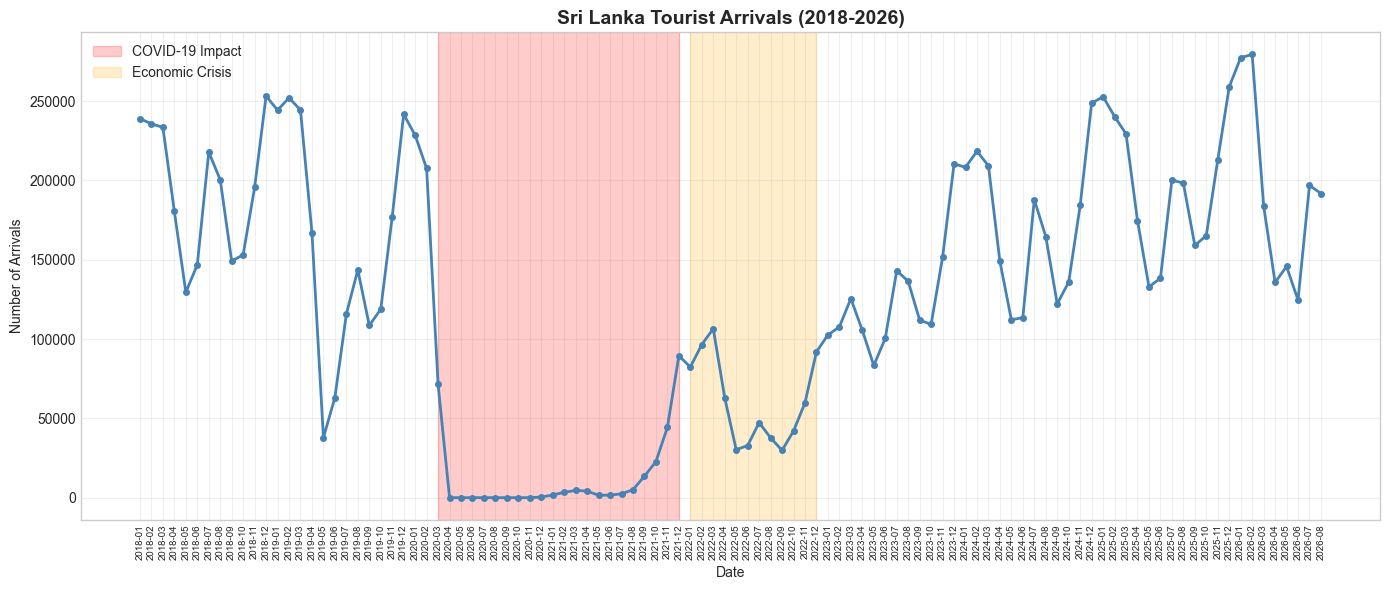


Pre-Crisis (2019) Average: 176,979
Crisis Period (2022) Average: 59,998
Recovery (2024) Average: 171,122
Latest (2026) Average: 191,890


In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot tourism data
ax.plot(tourism_df['year_month'], tourism_df['tourist_arrivals'], 
        marker='o', linewidth=2, markersize=4, color='steelblue')

# Highlight crisis period
ax.axvspan('2020-03', '2021-12', alpha=0.2, color='red', 
           label='COVID-19 Impact')
ax.axvspan('2022-01', '2022-12', alpha=0.2, color='orange',
           label='Economic Crisis')

ax.set_title('Sri Lanka Tourist Arrivals (2018-2026)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Arrivals')
ax.legend()
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='x', labelsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPre-Crisis (2019) Average: {tourism_df[tourism_df['year_month'] < '2020']['tourist_arrivals'].mean():,.0f}")
print(f"Crisis Period (2022) Average: {tourism_df[(tourism_df['year_month'] >= '2022-01') & (tourism_df['year_month'] <= '2022-12')]['tourist_arrivals'].mean():,.0f}")
print(f"Recovery (2024) Average: {tourism_df[tourism_df['year_month'].str.startswith('2024')]['tourist_arrivals'].mean():,.0f}")
print(f"Latest (2026) Average: {tourism_df[tourism_df['year_month'].str.startswith('2026')]['tourist_arrivals'].mean():,.0f}")


4.2 Exchange Rate (USD/LKR)

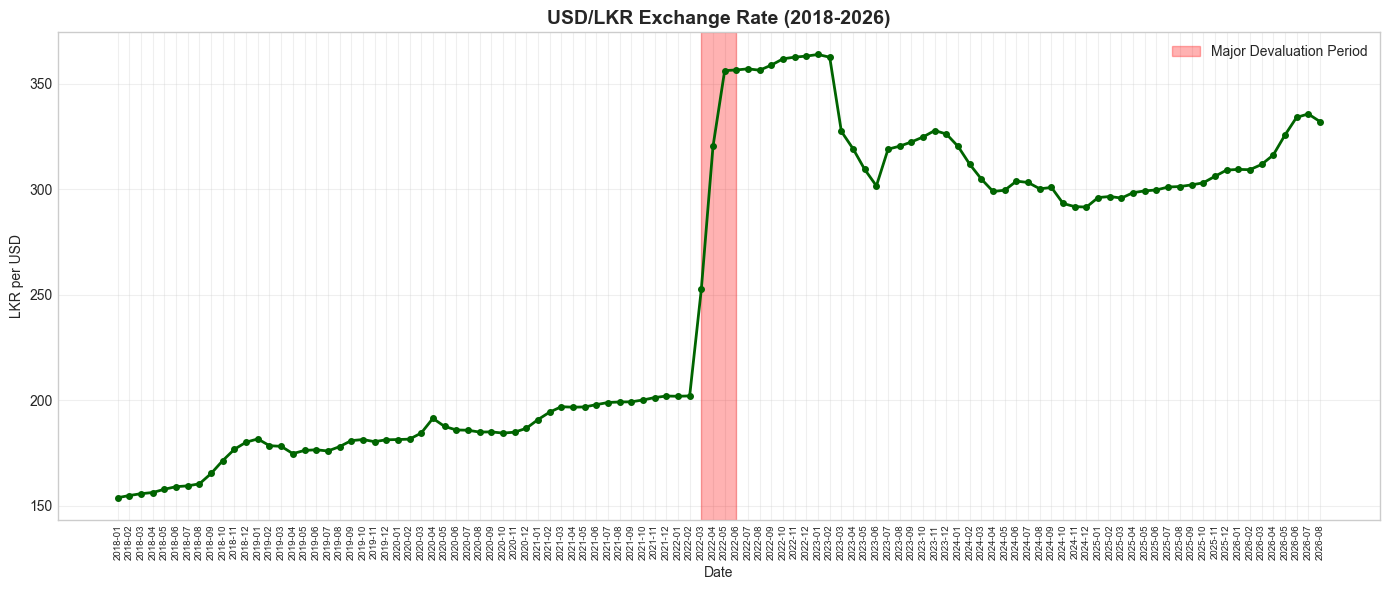


Pre-Crisis (2021) Average: 197.81
Crisis Peak (2022) Average: 320.84
Current (2026) Average: 321.81

Depreciation from 2021 to 2022: 62.2%


In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(exchange_df['year_month'], exchange_df['usd_lkr_rate'], 
        marker='o', linewidth=2, markersize=4, color='darkgreen')

# Highlight major devaluation
ax.axvspan('2022-03', '2022-06', alpha=0.3, color='red',
           label='Major Devaluation Period')

ax.set_title('USD/LKR Exchange Rate (2018-2026)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('LKR per USD')
ax.legend()
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='x', labelsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exchange rate statistics
print(f"\nPre-Crisis (2021) Average: {exchange_df[exchange_df['year_month'].str.startswith('2021')]['usd_lkr_rate'].mean():.2f}")
print(f"Crisis Peak (2022) Average: {exchange_df[exchange_df['year_month'].str.startswith('2022')]['usd_lkr_rate'].mean():.2f}")
print(f"Current (2026) Average: {exchange_df[exchange_df['year_month'].str.startswith('2026')]['usd_lkr_rate'].mean():.2f}")
print(f"\nDepreciation from 2021 to 2022: {((exchange_df[exchange_df['year_month'].str.startswith('2022')]['usd_lkr_rate'].mean() / exchange_df[exchange_df['year_month'].str.startswith('2021')]['usd_lkr_rate'].mean()) - 1) * 100:.1f}%")


4.3 Inflation Rate

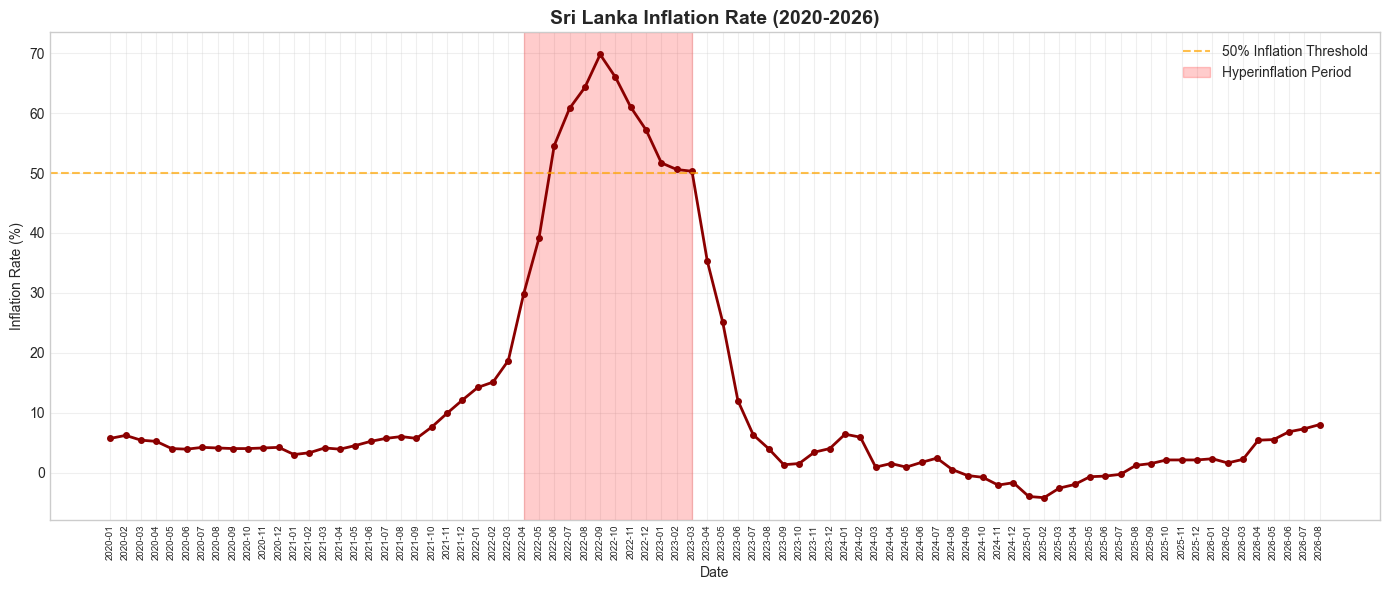


Pre-Crisis (2021) Average: 5.92%
Crisis Peak (2022) Average: 45.88%
Peak Month: 2022-09 (69.8%)
Current (2026) Average: 4.89%


In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(inflation_df['year_month'], inflation_df['inflation_rate'], 
        marker='o', linewidth=2, markersize=4, color='darkred')

# Highlight hyperinflation
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7,
           label='50% Inflation Threshold')
ax.axvspan('2022-04', '2023-03', alpha=0.2, color='red',
           label='Hyperinflation Period')

ax.set_title('Sri Lanka Inflation Rate (2020-2026)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Inflation Rate (%)')
ax.legend()
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='x', labelsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Inflation statistics
print(f"\nPre-Crisis (2021) Average: {inflation_df[inflation_df['year_month'].str.startswith('2021')]['inflation_rate'].mean():.2f}%")
print(f"Crisis Peak (2022) Average: {inflation_df[inflation_df['year_month'].str.startswith('2022')]['inflation_rate'].mean():.2f}%")
print(f"Peak Month: {inflation_df.loc[inflation_df['inflation_rate'].idxmax(), 'year_month']} ({inflation_df['inflation_rate'].max():.1f}%)")
print(f"Current (2026) Average: {inflation_df[inflation_df['year_month'].str.startswith('2026')]['inflation_rate'].mean():.2f}%")


5. Integrated Analysis: Sentiment vs Economic Indicators

5.1 Multi-Indicator Timeline

In [29]:
# Normalize data for comparison
merged_df_copy = merged_df.dropna(subset=['usd_lkr_rate', 'inflation_rate']).copy()

# Create normalized columns
merged_df_copy['tourist_norm'] = (merged_df_copy['tourist_arrivals'] - 
                                   merged_df_copy['tourist_arrivals'].mean()) / merged_df_copy['tourist_arrivals'].std()
merged_df_copy['exchange_norm'] = (merged_df_copy['usd_lkr_rate'] - 
                                    merged_df_copy['usd_lkr_rate'].mean()) / merged_df_copy['usd_lkr_rate'].std()
merged_df_copy['inflation_norm'] = (merged_df_copy['inflation_rate'] - 
                                     merged_df_copy['inflation_rate'].mean()) / merged_df_copy['inflation_rate'].std()
merged_df_copy['sentiment_norm'] = (merged_df_copy['sentiment_intensity'] - 
                                     merged_df_copy['sentiment_intensity'].mean()) / merged_df_copy['sentiment_intensity'].std()

fig = make_subplots(rows=4, cols=1, 
                    subplot_titles=('Sentiment Intensity', 'Tourist Arrivals', 
                                   'Exchange Rate (USD/LKR)', 'Inflation Rate'),
                    vertical_spacing=0.08)

# Sentiment
fig.add_trace(
    go.Scatter(
        x=merged_df_copy['year_month'],
        y=merged_df_copy['sentiment_norm'],
        name='Sentiment',
        line=dict(color='blue', width=2)
    ),
    row=1, col=1
)

# Tourism
fig.add_trace(
    go.Scatter(
        x=merged_df_copy['year_month'],
        y=merged_df_copy['tourist_norm'],
        name='Tourism',
        line=dict(color='green', width=2)
    ),
    row=2, col=1
)

# Exchange Rate
fig.add_trace(
    go.Scatter(
        x=merged_df_copy['year_month'],
        y=merged_df_copy['exchange_norm'],
        name='Exchange Rate',
        line=dict(color='red', width=2)
    ),
    row=3, col=1
)

# Inflation
fig.add_trace(
    go.Scatter(
        x=merged_df_copy['year_month'],
        y=merged_df_copy['inflation_norm'],
        name='Inflation',
        line=dict(color='orange', width=2)
    ),
    row=4, col=1
)

# Axis titles for each graph
subplot_labels = [
    ('Date', 'Normalized Sentiment Intensity'),
    ('Date', 'Normalized Tourist Arrivals'),
    ('Date', 'Normalized Exchange Rate'),
    ('Date', 'Normalized Inflation Rate')
]

for row, (x_title, y_title) in enumerate(subplot_labels, start=1):
    fig.update_xaxes(title_text=x_title, row=row, col=1, title_font_size=10)
    fig.update_yaxes(title_text=y_title, row=row, col=1, title_font_size=10)

# Add crisis highlight
fig.add_vrect(x0="2022-01", x1="2022-12",
              fillcolor="gray", opacity=0.2, line_width=0)

fig.update_layout(height=900, 
                  showlegend=False,
                  template='plotly_white',
                  title_text="Normalized Economic Indicators vs Sentiment (2020-2026)",
                  title_font_size=16)

fig.update_xaxes(title_text="Date", row=4, col=1)
fig.show()

5.2 Correlation Heatmap

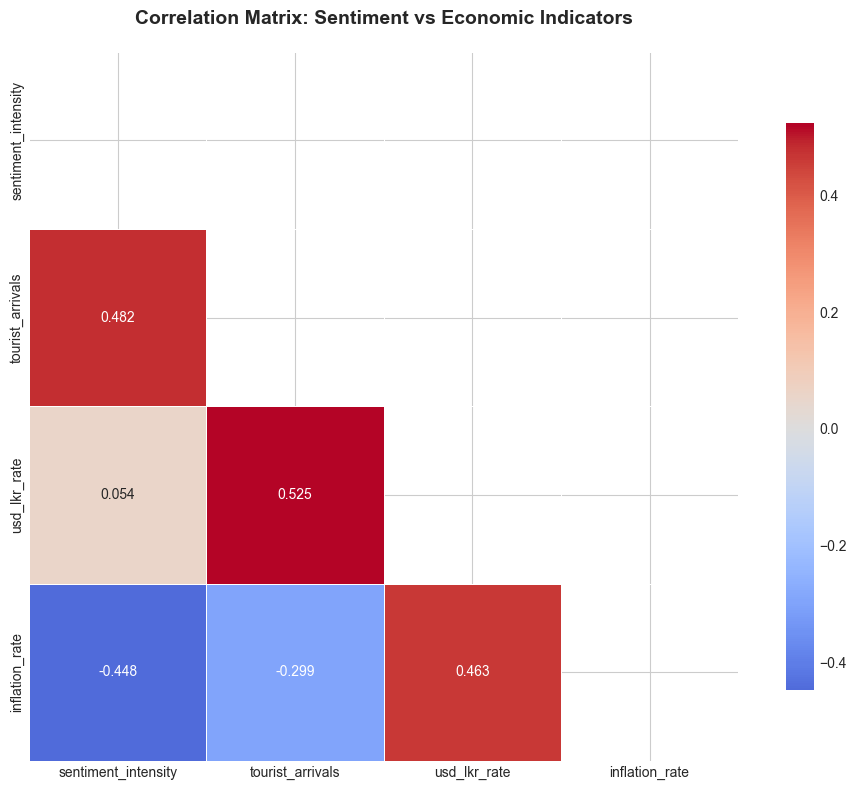

CORRELATION COEFFICIENTS WITH SENTIMENT

Tourist Arrivals: 0.4823
Exchange Rate: 0.0543
Inflation Rate: -0.4481


In [31]:
# Prepare correlation data
corr_data = merged_df_copy[['sentiment_intensity', 'tourist_arrivals', 
                            'usd_lkr_rate', 'inflation_rate']].dropna()

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Sentiment vs Economic Indicators', 
          fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Print correlation values
print("CORRELATION COEFFICIENTS WITH SENTIMENT")
print(f"\nTourist Arrivals: {corr_matrix.loc['sentiment_intensity', 'tourist_arrivals']:.4f}")
print(f"Exchange Rate: {corr_matrix.loc['sentiment_intensity', 'usd_lkr_rate']:.4f}")
print(f"Inflation Rate: {corr_matrix.loc['sentiment_intensity', 'inflation_rate']:.4f}")


6. Key Events Impact Analysis

6.1 Events Timeline

In [34]:
# Create events visualization
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_index['year_month'],
    y=monthly_index['sentiment_intensity'],
    mode='lines',
    name='Sentiment Intensity',
    line=dict(color='steelblue', width=2)
))

# Add event markers
for idx, event in key_events.iterrows():
    fig.add_trace(go.Scatter(
        x=[event['date']],
        y=[monthly_index[monthly_index['year_month'] == event['date'].strftime('%Y-%m')]['sentiment_intensity'].values[0] 
           if len(monthly_index[monthly_index['year_month'] == event['date'].strftime('%Y-%m')]) > 0 else 0],
        mode='markers',
        name=f"{event['label']} ({event['category']})",
        marker=dict(size=10, symbol='star'),
        text=f"{event['date'].strftime('%Y-%m-%d')}: {event['label']}",
        hoverinfo='text+name'
    ))

fig.update_layout(
    title='Key Economic & Political Events Impact on Sentiment',
    xaxis_title='Date',
    yaxis_title='Sentiment Intensity',
    height=600,
    width=1000,
    template='plotly_white',
    hovermode='closest'
)

fig.show()


6.2 Event Categories

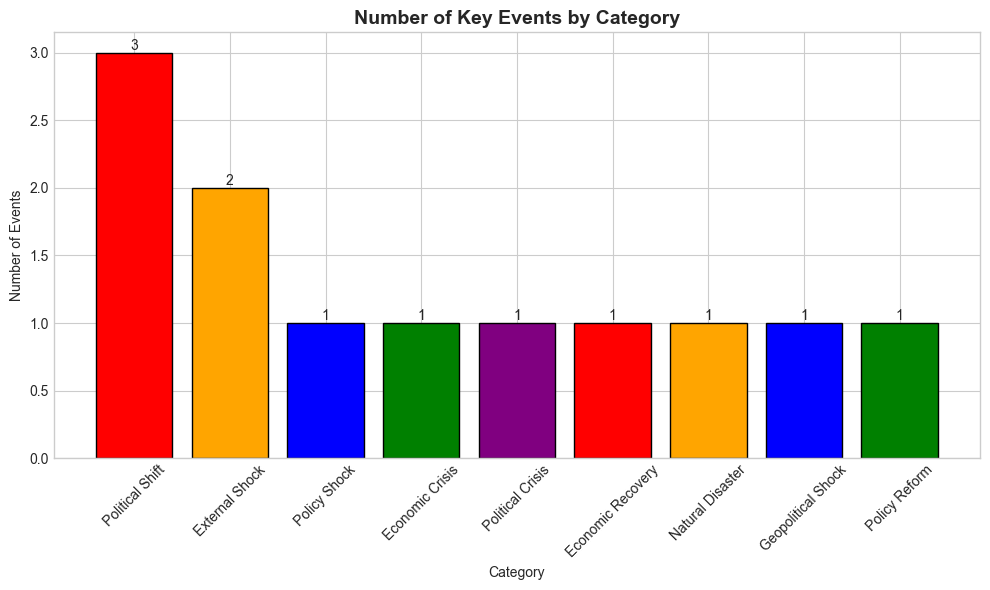

In [35]:
if 'category' in key_events.columns:
    event_counts = key_events['category'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(event_counts.index, event_counts.values, 
                  color=['red', 'orange', 'blue', 'green', 'purple'][:len(event_counts)],
                  edgecolor='black')
    
    ax.set_title('Number of Key Events by Category', fontweight='bold', fontsize=14)
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of Events')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

7. Lag Correlation Analysis

7.1 Sentiment as Leading/Lagging Indicator

LAG CORRELATION ANALYSIS

 TOURIST ARRIVALS:
  Best Correlation: 0.4823
  Lag: 0 months (Contemporaneous)
  Interpretation: Sentiment and tourist arrivals move together

 USD LKR RATE:
  Best Correlation: 0.1558
  Lag: -3 months (Sentiment Lags)
  Interpretation: Sentiment changes -3 months AFTER usd lkr rate

 INFLATION RATE:
  Best Correlation: -0.4918
  Lag: 2 months (Sentiment Leads)
  Interpretation: Sentiment changes 2 months BEFORE inflation rate


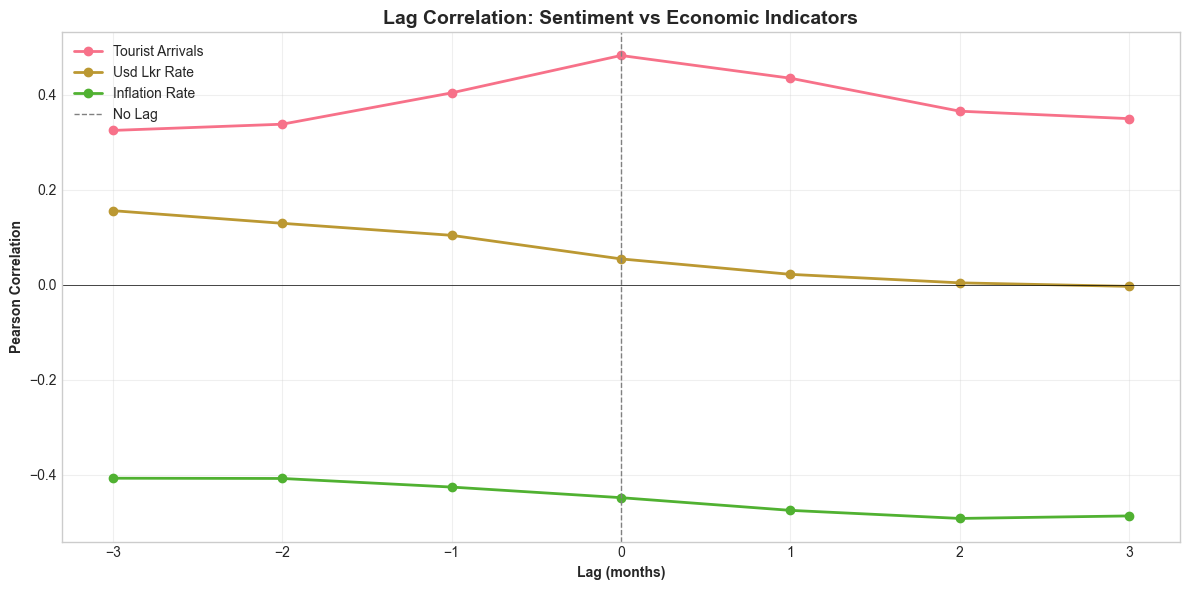

In [38]:
if not correlation_df.empty:
    print("LAG CORRELATION ANALYSIS")
    
    # Display lag correlation for each indicator
    for indicator in correlation_df['indicator'].unique():
        print(f"\n {indicator.upper().replace('_', ' ')}:")
        indicator_corr = correlation_df[correlation_df['indicator'] == indicator]
        
        # Find best lag
        best_lag = indicator_corr.loc[indicator_corr['pearson_corr'].abs().idxmax()]
        
        print(f"  Best Correlation: {best_lag['pearson_corr']:.4f}")
        print(f"  Lag: {int(best_lag['lag_months'])} months ({best_lag['direction']})")
        print(f"  Interpretation: ", end="")
        
        if best_lag['direction'] == 'Sentiment Leads':
            print(f"Sentiment changes {int(best_lag['lag_months'])} months BEFORE {indicator.replace('_', ' ')}")
        elif best_lag['direction'] == 'Sentiment Lags':
            print(f"Sentiment changes {int(best_lag['lag_months'])} months AFTER {indicator.replace('_', ' ')}")
        else:
            print(f"Sentiment and {indicator.replace('_', ' ')} move together")
    
    # Visualize lag correlations
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for indicator in correlation_df['indicator'].unique():
        indicator_corr = correlation_df[correlation_df['indicator'] == indicator]
        ax.plot(indicator_corr['lag_months'], indicator_corr['pearson_corr'], 
                marker='o', label=indicator.replace('_', ' ').title(), linewidth=2)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='No Lag')
    ax.set_xlabel('Lag (months)', fontweight='bold')
    ax.set_ylabel('Pearson Correlation', fontweight='bold')
    ax.set_title('Lag Correlation: Sentiment vs Economic Indicators', 
                 fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()